# CCM summary result grids

This notebook produces the three extended result grids: Δρ, max-library-size ρ, and optimal lag, straight from the single precomputed `mixed/tmp/final_result_grid.parquet` file.

No raw observations, object grids, or individual CCM outputs get read here; the
figure object grid is rebuilt in memory from the summary table.

Where the previous notebook shows only the four main-text dyads untreated, this one
lays out all ten dyads (four main-text plus six SI robustness dyads: Döring22,
Seierstad14 GISP2/NGRIP, Martin24 GISP2/NGRIP, and the Tian22 constant-TSI null test)
as columns, crossed with all three treatments (untreated, linearly detrended, 1-kyr
high-pass) as rows. This is Fig. S6's full 3×10 layout, and it's the evidence that
the ALLEY00 result isn't sensitive to site, age model, or observation type. The same
summary table also drives Fig. S9 (final ρ instead of Δρ) and Fig. S7 (the optimal
lag chosen at each cell), rendered by the two cells further down.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.colors as mcolors

from cedarkit.viz.panels import ResultsGrid
from cedarkit.viz.grids import GridCell, SummaryGrid
from cedarkit.core.relationship import Relationship
from cedarkit.utils.plotting import save_figure

warnings.filterwarnings("ignore", category=FutureWarning)
notebook_name = "plot__DataGroup_grid__final_result_grid"


stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])
figures_dir = stem / "figures" / notebook_name
figures_dir.mkdir(parents=True, exist_ok=True)
final_result_grid_path = stem / "hol_temp_tsi_ccm" / "mixed" / "tmp" / "final_result_grid.parquet"



## Load the summary data and construct the figure object grid

The layout and row categories are retained from the source notebook.  Each
`GridCell.output` is a small DataFrame containing only the precomputed rows
for that panel.


In [2]:
results = pd.read_parquet(final_result_grid_path)
selection_policy = "object_grid_precomputed"
results = results.loc[results.selection_policy.eq(selection_policy)].copy()

# Some legacy object-grid scalars were serialized as strings.  The plot
# columns are numerical regardless of their source representation.
for numeric_col in [
    "E", "tau", "Tp", "knn", "delta_rho", "maxlibsize_rho", "lag",
    "peak_start", "peak_end", "surr_rx_count", "surr_rx_count_outperforming",
    "surr_rx_outperforming_frac", "surr_ry_count",
    "surr_ry_count_outperforming", "surr_ry_outperforming_frac",
]:
    if numeric_col in results:
        results[numeric_col] = pd.to_numeric(results[numeric_col], errors="coerce")

required_columns = {
    "proj_name", "pair_label", "row_category", "selection_policy", "E", "tau",
    "delta_rho", "maxlibsize_rho", "lag", "peak_end",
    "surr_rx_outperforming_frac", "surr_ry_outperforming_frac", "var_x", "var_y",
}
missing_columns = required_columns.difference(results.columns)
assert not missing_columns, f"Final result grid lacks: {sorted(missing_columns)}"

pair_specs = [
    ("Tian-Wu", "Tian22HT115kaALLGMST_Wu18TSI", "Tian22HT115kaALLGMSTLinear_Wu18TSILinear", "tian22ht115kaallgmst1kyrfir_wu18tsianom1kyrfir"),
    ("Erb-Wu", "Erb22daGMST_Wu18TSI", "Erb22daGMSTLinear_Wu18TSILinear", "erb22dagmst1kyrfir_wu18tsianom1kyrfir"),
    ("Erb-Vieira", "Erb22daGMST_Vieira11TSI", "Erb22daGMSTLinear_Vieira11TSILinear", "erb22dagmst1kyrfir_vieira11tsianom1kyrfir"),
    ("Alley-Wu", "GISP2Alley00Tanom_Wu18TSI", "GISP2Alley00TanomLinear_Wu18TSILinear", "alley00gisp2multiproxy1kyrfir_wu18tsianom1kyrfir"),
    ("Alley-Vieira", "GISP2Alley00Tanom_Vieira11TSI", "GISP2Alley00TanomLinear_Vieira11TSILinear", "alley00gisp2multiproxy1kyrfir_vieira11tsianom1kyrfir"),
    ("Doering-Wu", "GISP2Doering22T15N_Wu18TSI", "GISP2Doering22T15NLinear_Wu18TSILinear", "doering22gisp2t15n1kyrfir_wu18tsianom1kyrfir"),
    ("GISP2 Seierstad-Wu", "GISP2Seierstad14d18O_Wu18TSI", "GISP2Seierstad14d18OLinear_Wu18TSILinear", "seierstad14gisp2d18o1kyrfir_wu18tsianom1kyrfir"),
    ("NGRIP Seierstad-Wu", "NGRIP1Seierstad14d18O_Wu18TSI", "NGRIP1Seierstad14d18OLinear_Wu18TSILinear", "seierstad14ngrip1d18o1kyrfir_wu18tsianom1kyrfir"),
    ("GISP2 Martin-Wu", "GISP2Martin24Tanom_Wu18TSI", "GISP2Martin24TanomLinear_Wu18TSILinear", "martin24gisp2tanom1kyrfir_wu18tsianom1kyrfir"),
    ("NGRIP Martin-Wu", "NGRIPMartin24Tanom_Wu18TSI", "NGRIPMartin24TanomLinear_Wu18TSILinear", "martin24ngriptanom1kyrfir_wu18tsianom1kyrfir"),
]
row_categories = ["original", "lineardetrended", "1kyrfir"]
row_labels = ["Untreated", "Linear Detrend", "1kyr High-Pass"]

new_grid_d2 = {}
for col, (pair_label, *proj_names) in enumerate(pair_specs):
    for row, (row_category, proj_name) in enumerate(zip(row_categories, proj_names)):
        grid_df = results.loc[
            (results.proj_name == proj_name) & (results.row_category == row_category)
        ].copy()
        if grid_df.empty:
            new_grid_d2[(row, col)] = None
            continue
        if grid_df.duplicated(["E", "tau"]).any():
            raise ValueError(f"Duplicated E/tau rows for {proj_name}")
        # Match the source notebook's final plotting domain.
        grid_df = grid_df.loc[(grid_df.tau < 8) & (grid_df.E < 9)].copy()
        cell = GridCell(row, col, output=grid_df)
        cell.row_labels = [row_labels[row] + "\n\n" + r"$\tau$; snippet timestep (decades)"]
        cell.col_labels = [r"$E$; time points/snippet"]
        cell.title_labels = [pair_label]
        cell.ylims = [grid_df.maxlibsize_rho.quantile(.1), grid_df.maxlibsize_rho.quantile(.7)]
        cell.relationships = Relationship(
            var_x=grid_df.var_x.dropna().iloc[0], var_y=grid_df.var_y.dropna().iloc[0]
        )
        new_grid_d2[(row, col)] = cell

new_grid_d2_adjusted = new_grid_d2.copy()
project_pairs = pair_specs
print(f"Loaded {sum(cell is not None for cell in new_grid_d2.values())} panels from {len(results):,} summary rows.")


Loaded 30 panels from 1,242 summary rows.


## Shared plotting helpers


In [3]:
def grid_limits(cells, hue_var, floor=0, default_ceiling=.4):
    values = [cell.output[hue_var] for cell in cells.values() if cell is not None]
    values = pd.concat(values).dropna()
    return max(floor, float(values.quantile(.1))), max(default_ceiling, float(values.quantile(.7)))


def make_results_grid(hue_var, cbar_label, stem, *, palette, show_half_moons=True,
                      lag_filter=lambda x: x < 0, norm=None, vlims=None):
    rows, cols = 3, len(project_pairs)
    gridplot = SummaryGrid(rows, cols + 1, width_ratios=[1] * cols + [.1])
    gridplot.set_font_sizes(context="poster", multiplier=4)
    gridplot.make_grid(figsize=(3.2 * cols, 8.5), wspace=.06, hspace=-.12)
    gridplot.palette = palette
    gridplot.norm = norm
    gridplot.vlims = vlims if vlims is not None else grid_limits(new_grid_d2_adjusted, hue_var)
    gridplot.cbar_ax = gridplot.get_ax(0, cols)

    for (row, col), cell_obj in new_grid_d2_adjusted.items():
        ax = gridplot.get_ax(row, col)
        ax.set_ylabel(r"$\tau$")
        if cell_obj is None:
            gridplot.set_ax(row, col, ax, entry_type=None)
            continue
        cell_obj.ylims = gridplot.vlims
        res_grid = ResultsGrid(cell_obj.relationships, ax=ax, palette=palette,
                               hue_var=hue_var, show_half_moons=show_half_moons,
                               lag_filter=lag_filter, norm=norm)
        res_grid.populate_from_cellobj(cell_obj)
        res_grid.plot_heatmap(cell_obj.output.copy())
        res_grid.add_half_moons(cell_obj.output.copy())
        res_grid.mask_nan_cells(cell_obj.output.copy())
        res_grid.tidy_grid()
        gridplot.add_handles_labels(res_grid.line_handles, res_grid.line_labels, kind="line")
        if res_grid.ax is not None:
            res_grid.ax.set_yticklabels([f"{1 + int(tick)}" for tick in res_grid.ax.get_yticks()])
            gridplot.set_ax(row, col, res_grid.ax, entry_type="heatmap")
            gridplot.marker_d.update(res_grid.marker_d)
            gridplot.sizes = res_grid.sizes
        else:
            gridplot.set_ax(row, col, ax, entry_type=None)

    for col, (title, *_) in enumerate(project_pairs):
        gridplot.get_ax(0, col).set_title(title)
    gridplot.get_ax(2, cols).remove()
    gridplot.get_ax(1, cols).remove()
    gridplot.cbar_label = cbar_label
    if show_half_moons:
        gridplot.create_custom_legend(bbox_to_anchor=(0, .95))
    gridplot.tidy_rows(ylim_by="central", supylabel_offset=.11, title_rows=[0])
    gridplot.make_colorbar()
    save_figure(gridplot.fig, figures_dir, stem=stem, dry_run=True)
    return gridplot


## Δρ grid (Figure S6)

Same statistic and half-moon convention as the main-text Fig. 3 (Δρ is the
improvement in CCM skill with library size; half-moon size is the fraction of
surrogates that matched or beat the real relationship), just extended to every dyad
and treatment.


   tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
0    1  4        NaN                         0.0                         0.0 dyad_df hue_var with nans
   tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
0    1  4        NaN                         0.0                         0.0 dyad_df hue_var with nans
   tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
0    1  4        NaN                         0.0                         0.0 dyad_df hue_var with nans
    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
0     1  4        NaN                         0.0                       0.015
1     1  5        NaN                         0.0                       0.010
17    4  6        NaN                         0.0                       0.030
18    4  7        NaN                         0.0                       0.040
25    6  4        NaN                         0.0                     

    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
0     1  4        NaN                         0.0                       0.015
1     1  5        NaN                         0.0                       0.010
17    4  6        NaN                         0.0                       0.030
18    4  7        NaN                         0.0                       0.040
25    6  4        NaN                         0.0                       0.010
30    7  4        NaN                         0.0                       0.025 dyad_df hue_var with nans
    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
0     1  4        NaN                         0.0                       0.015
1     1  5        NaN                         0.0                       0.010
17    4  6        NaN                         0.0                       0.030
18    4  7        NaN                         0.0                       0.040
25    6  4        NaN                 

    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
0     1  4        NaN                         0.0                         0.0
19    4  8        NaN                         0.0                         0.0 dyad_df hue_var with nans
    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
0     1  4        NaN                         0.0                         0.0
19    4  8        NaN                         0.0                         0.0 dyad_df hue_var with nans
    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
0     1  4        NaN                         0.0                         0.0
19    4  8        NaN                         0.0                         0.0 dyad_df hue_var with nans


    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
13    3  7        NaN                         0.0                       0.175
29    6  8        NaN                         0.0                       0.120 dyad_df hue_var with nans
    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
13    3  7        NaN                         0.0                       0.175
29    6  8        NaN                         0.0                       0.120 dyad_df hue_var with nans
    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
13    3  7        NaN                         0.0                       0.175
29    6  8        NaN                         0.0                       0.120 dyad_df hue_var with nans


   tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
4    1  8        NaN                        0.20                        0.12
6    2  5        NaN                        0.29                        0.20
7    2  6        NaN                        0.37                        0.26 dyad_df hue_var with nans
   tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
4    1  8        NaN                        0.20                        0.12
6    2  5        NaN                        0.29                        0.20
7    2  6        NaN                        0.37                        0.26 dyad_df hue_var with nans
   tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
4    1  8        NaN                        0.20                        0.12
6    2  5        NaN                        0.29                        0.20
7    2  6        NaN                        0.37                        0.26 dyad_df hue_var with nan

...

    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
14    3  8        NaN                         0.0                       0.275
19    4  8        NaN                         0.0                       0.285
22    5  6        NaN                         0.0                       0.360
23    5  7        NaN                         0.0                       0.175
24    5  8        NaN                         0.0                       0.270
27    6  6        NaN                         0.0                       0.270
28    6  7        NaN                         0.0                       0.200
29    6  8        NaN                         0.0                       0.035
31    7  5        NaN                         0.0                       0.055
32    7  6        NaN                         0.0                       0.015
33    7  7        NaN                         0.0                       0.005
34    7  8        NaN                         0.0               

/Users/jlanders/PycharmProjects/CCM_software/cedar_util/cedarkit/viz/panels.py:340: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax.legend().remove()


    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
24    5  8        NaN                       0.010                       0.085
28    6  7        NaN                       0.015                       0.095
29    6  8        NaN                       0.025                       0.180
32    7  6        NaN                       0.010                       0.090 dyad_df hue_var with nans
    tau  E  delta_rho  surr_ry_outperforming_frac  surr_rx_outperforming_frac
24    5  8        NaN                       0.010                       0.085
28    6  7        NaN                       0.015                       0.095
29    6  8        NaN                       0.025                       0.180
32    7  6        NaN                       0.010                       0.090 dyad_df hue_var with nans


/Users/jlanders/PycharmProjects/CCM_software/cedar_util/cedarkit/viz/grids.py:586: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved /Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/figures/plot__DataGroup_grid__final_result_grid/FigS6_grid_3xn_fullspread__results.pdf


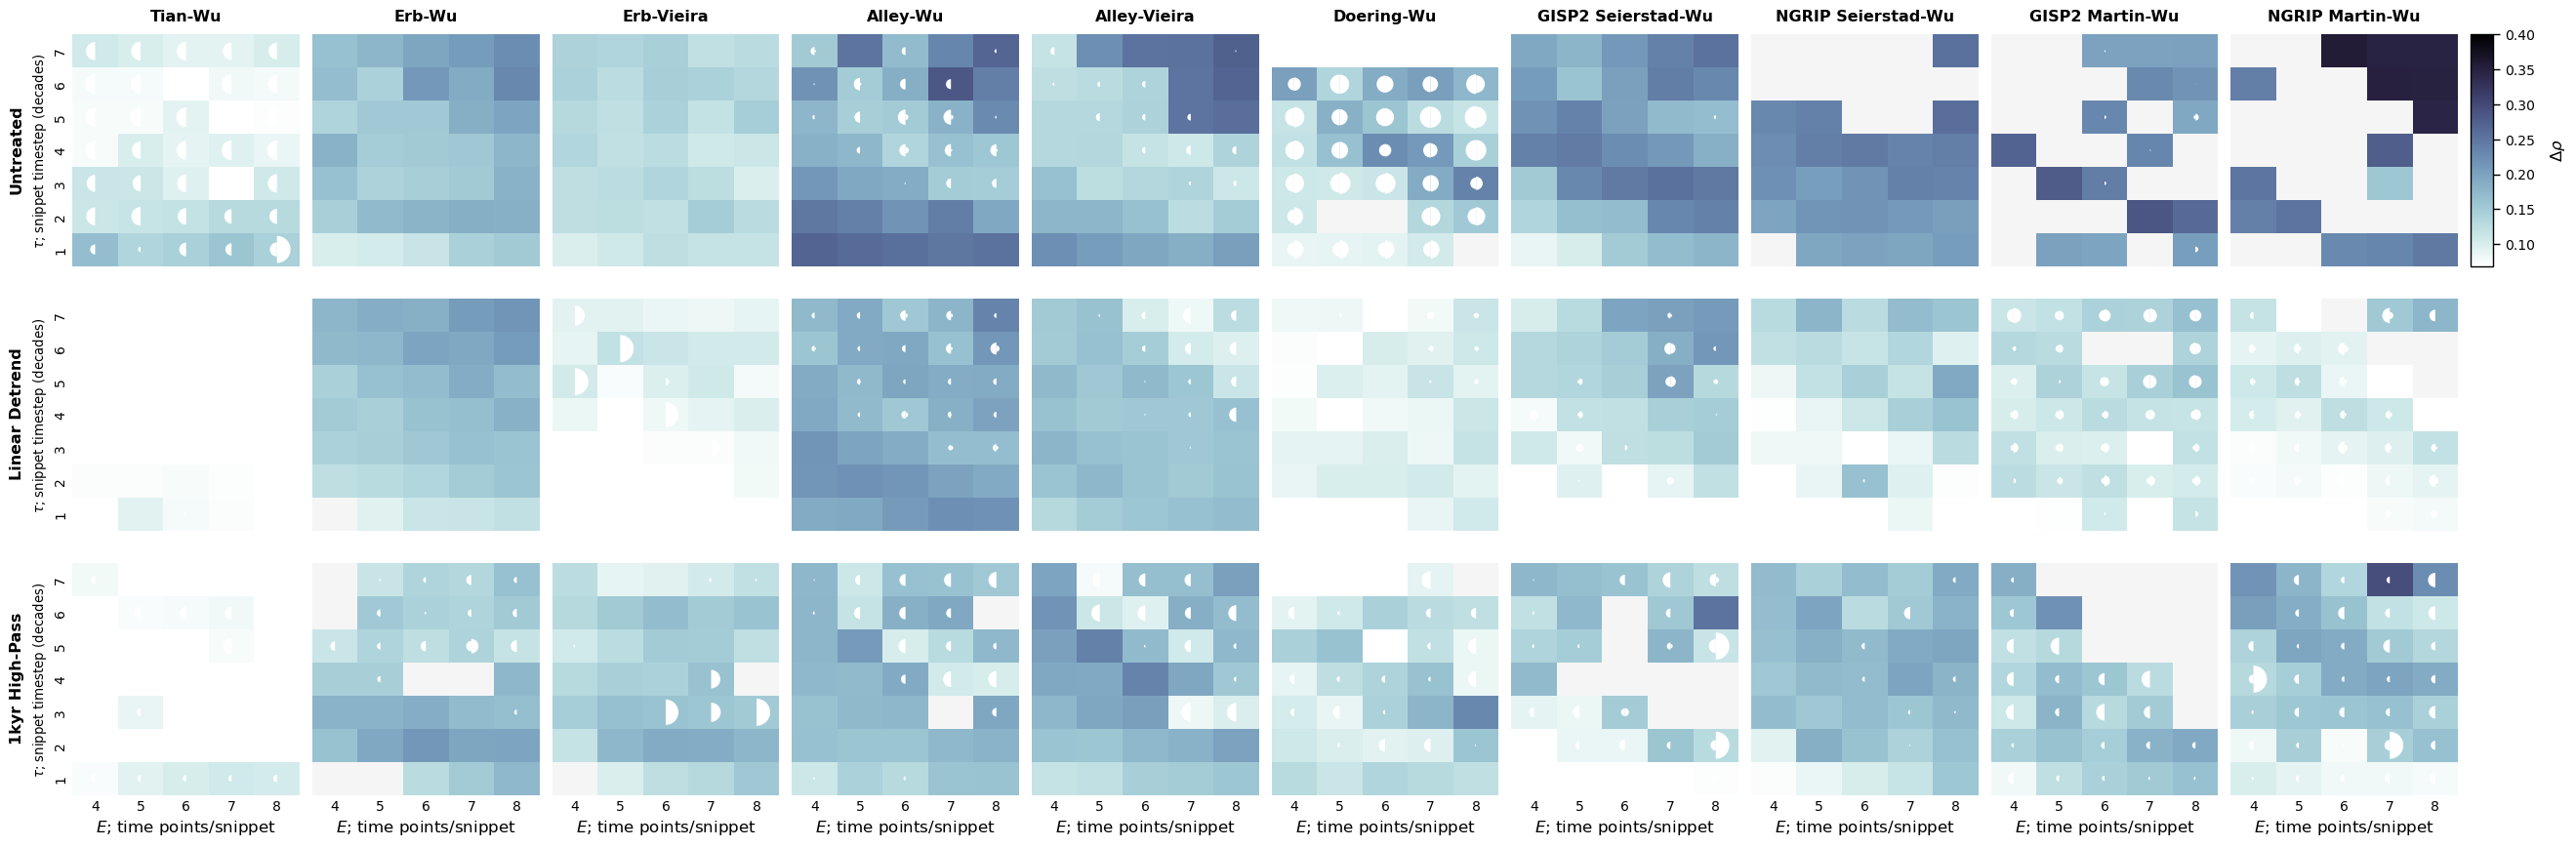

In [4]:
delta_palette = sns.cubehelix_palette(start=.18, rot=-.28, light=1, dark=0,
                                      gamma=1, reverse=False, as_cmap=True)
delta_grid = make_results_grid(
    "delta_rho", r"$\Delta \rho$", "FigS6_grid_3xn_fullspread__results",
    palette=delta_palette, show_half_moons=True,
)


### Interpretation

The paper's own reading of this stays fairly high-level, since detrending and
filtering both carry some risk of introducing artifacts. Broadly: untreated dyads
involving ERB22 and the Seierstad14/Alley00 GISP2 records show discernible
influence. Linear detrending turns up newly visible influence in Döring22 and
Seierstad14-NGRIP. High-pass filtering tends to shrink the number of significant
configurations overall, with one exception: Martin24-NGRIP is significant only
after high-pass filtering. The one dyad that stays null no matter the treatment is
Tian22, the constant-TSI GCM control, which is exactly the negative result it's
there to produce.


## Max-library-size ρ grid (Figure S9)

This grid recolors the same cells by final ρ, CCM skill at the largest library size,
instead of its improvement Δρ: the absolute predictive skill each configuration
reaches, rather than how much it grew getting there. There's no half-moon
significance overlay here (`show_half_moons=False`).


   tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
0    1  4             NaN                         0.0   

   surr_rx_outperforming_frac  
0                         0.0   dyad_df hue_var with nans
   tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
0    1  4             NaN                         0.0   

   surr_rx_outperforming_frac  
0                         0.0   dyad_df hue_var with nans
    tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
0     1  4             NaN                         0.0   
1     1  5             NaN                         0.0   
17    4  6             NaN                         0.0   
18    4  7             NaN                         0.0   
25    6  4             NaN                         0.0   
30    7  4             NaN                         0.0   

    surr_rx_outperforming_frac  
0                        0.015  
1                        0.010  
17                       0.030  
18                       0.040  
25                

    tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
0     1  4             NaN                         0.0   
1     1  5             NaN                         0.0   
17    4  6             NaN                         0.0   
18    4  7             NaN                         0.0   
25    6  4             NaN                         0.0   
30    7  4             NaN                         0.0   

    surr_rx_outperforming_frac  
0                        0.015  
1                        0.010  
17                       0.030  
18                       0.040  
25                       0.010  
30                       0.025   dyad_df hue_var with nans


    tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
0     1  4             NaN                         0.0   
19    4  8             NaN                         0.0   

    surr_rx_outperforming_frac  
0                          0.0  
19                         0.0   dyad_df hue_var with nans
    tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
0     1  4             NaN                         0.0   
19    4  8             NaN                         0.0   

    surr_rx_outperforming_frac  
0                          0.0  
19                         0.0   dyad_df hue_var with nans


    tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
13    3  7             NaN                         0.0   
29    6  8             NaN                         0.0   

    surr_rx_outperforming_frac  
13                       0.175  
29                       0.120   dyad_df hue_var with nans
    tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
13    3  7             NaN                         0.0   
29    6  8             NaN                         0.0   

    surr_rx_outperforming_frac  
13                       0.175  
29                       0.120   dyad_df hue_var with nans


   tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
4    1  8             NaN                        0.20   
6    2  5             NaN                        0.29   
7    2  6             NaN                        0.37   

   surr_rx_outperforming_frac  
4                        0.12  
6                        0.20  
7                        0.26   dyad_df hue_var with nans
   tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
4    1  8             NaN                        0.20   
6    2  5             NaN                        0.29   
7    2  6             NaN                        0.37   

   surr_rx_outperforming_frac  
4                        0.12  
6                        0.20  
7                        0.26   dyad_df hue_var with nans


...

    tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
0     1  4             NaN                    0.020000   
3     1  7             NaN                    0.040000   
5     2  4             NaN                    0.020000   
6     2  5             NaN                    0.015000   
7     2  6             NaN                    0.005000   
10    3  4             NaN                    0.015000   
13    3  7             NaN                    0.000000   
14    3  8             NaN                    0.000000   
16    4  5             NaN                    0.000000   
17    4  6             NaN                    0.000000   
19    4  8             NaN                    0.005435   
20    5  4             NaN                    0.005435   
21    5  5             NaN                    0.000000   
23    5  7             NaN                    0.071006   
25    6  4             NaN                    0.015306   
26    6  5             NaN                    0.021053   
27    6  6    

    tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
27    6  6             NaN                        0.12   
28    6  7             NaN                        0.06   

    surr_rx_outperforming_frac  
27                       0.080  
28                       0.035   dyad_df hue_var with nans
    tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
14    3  8             NaN                         0.0   
19    4  8             NaN                         0.0   
22    5  6             NaN                         0.0   
23    5  7             NaN                         0.0   
24    5  8             NaN                         0.0   
27    6  6             NaN                         0.0   
28    6  7             NaN                         0.0   
29    6  8             NaN                         0.0   
31    7  5             NaN                         0.0   
32    7  6             NaN                         0.0   
33    7  7             NaN                         0.0   
34  

    tau  E  maxlibsize_rho  surr_ry_outperforming_frac  \
0     1  4             NaN                         NaN   
1     1  5             NaN                         NaN   
7     2  6             NaN                         NaN   
8     2  7             NaN                         NaN   
9     2  8             NaN                         NaN   
11    3  5             NaN                         NaN   
12    3  6             NaN                         NaN   
14    3  8             NaN                         NaN   
15    4  4             NaN                         NaN   
16    4  5             NaN                         NaN   
17    4  6             NaN                         NaN   
19    4  8             NaN                         NaN   
20    5  4             NaN                         NaN   
21    5  5             NaN                         NaN   
22    5  6             NaN                         NaN   
23    5  7             NaN                         NaN   
26    6  5    

/Users/jlanders/PycharmProjects/CCM_software/cedar_util/cedarkit/viz/grids.py:586: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved /Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/figures/plot__DataGroup_grid__final_result_grid/FigS9_grid_3xn_fullspread__finalrho.pdf


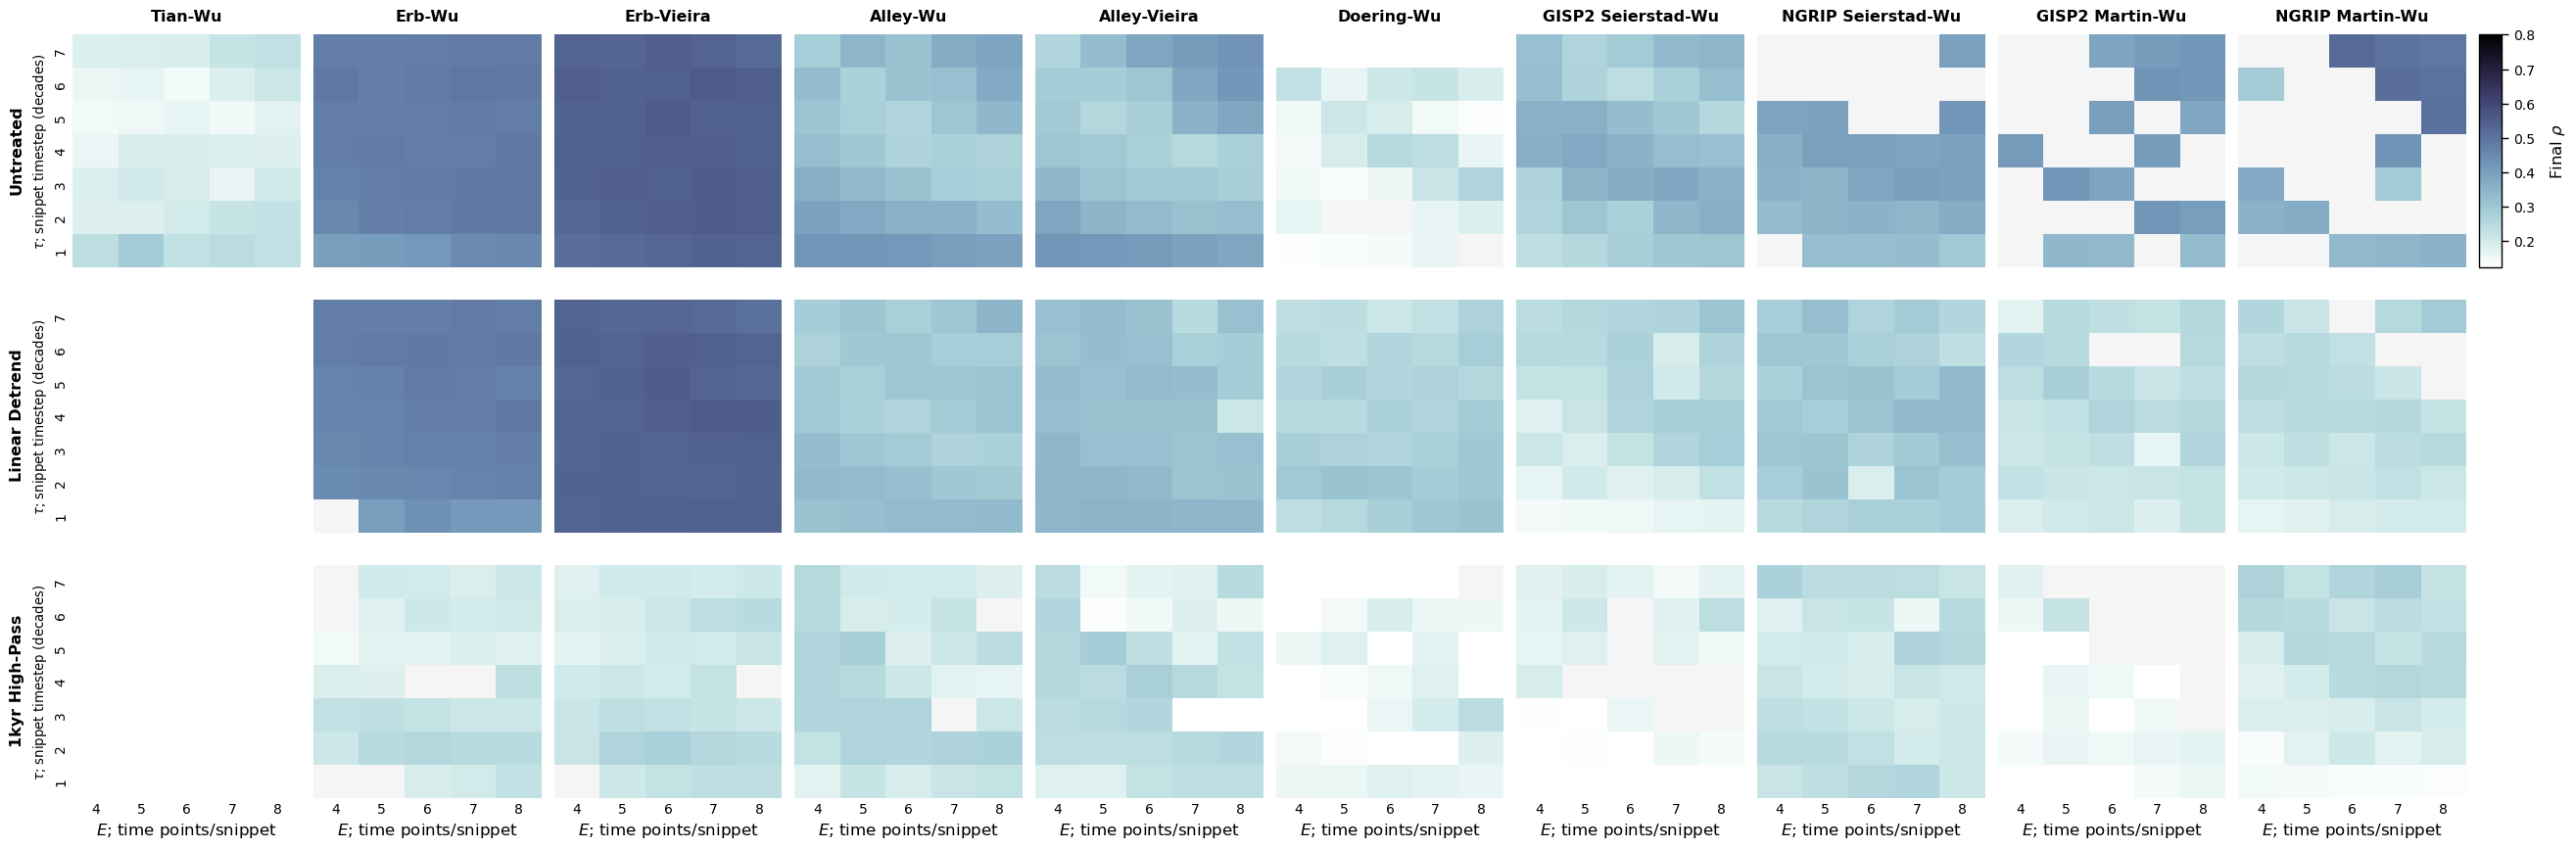

In [5]:
rho_palette = sns.cubehelix_palette(start=.18, rot=-.28, light=1, dark=0,
                                    gamma=1, reverse=False, as_cmap=True)
rho_grid = make_results_grid(
    "maxlibsize_rho", r"Final $\rho$", "FigS9_grid_3xn_fullspread__finalrho",
    palette=rho_palette, show_half_moons=False,
    vlims=grid_limits(new_grid_d2_adjusted, "maxlibsize_rho", floor=0, default_ceiling=.8),
)


### Interpretation

Read this figure alongside Fig. S6, not as an independent significance claim: high
final ρ alone doesn't establish causality without the accompanying Δρ and
surrogate tests. Its main use here is as the quantity behind the comparison against
simple correlation (Fig. S10 is this grid minus Fig. S8).


## Optimal-lag grid (Figure S7)

This recolors each configuration by its selected lag ℓ, in decades, with positive
values meaning TSI leads temperature, instead of by skill. The custom
`MultiBreakNorm` and diverging palette put visual emphasis on the ℓ ≈ 0 region,
because the sign and size of the optimal lag carries its own physical information.


/Users/jlanders/PycharmProjects/CCM_software/cedar_util/cedarkit/viz/grids.py:586: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved /Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/figures/plot__DataGroup_grid__final_result_grid/FigS7_grid_3xn_fullspread__lag.pdf


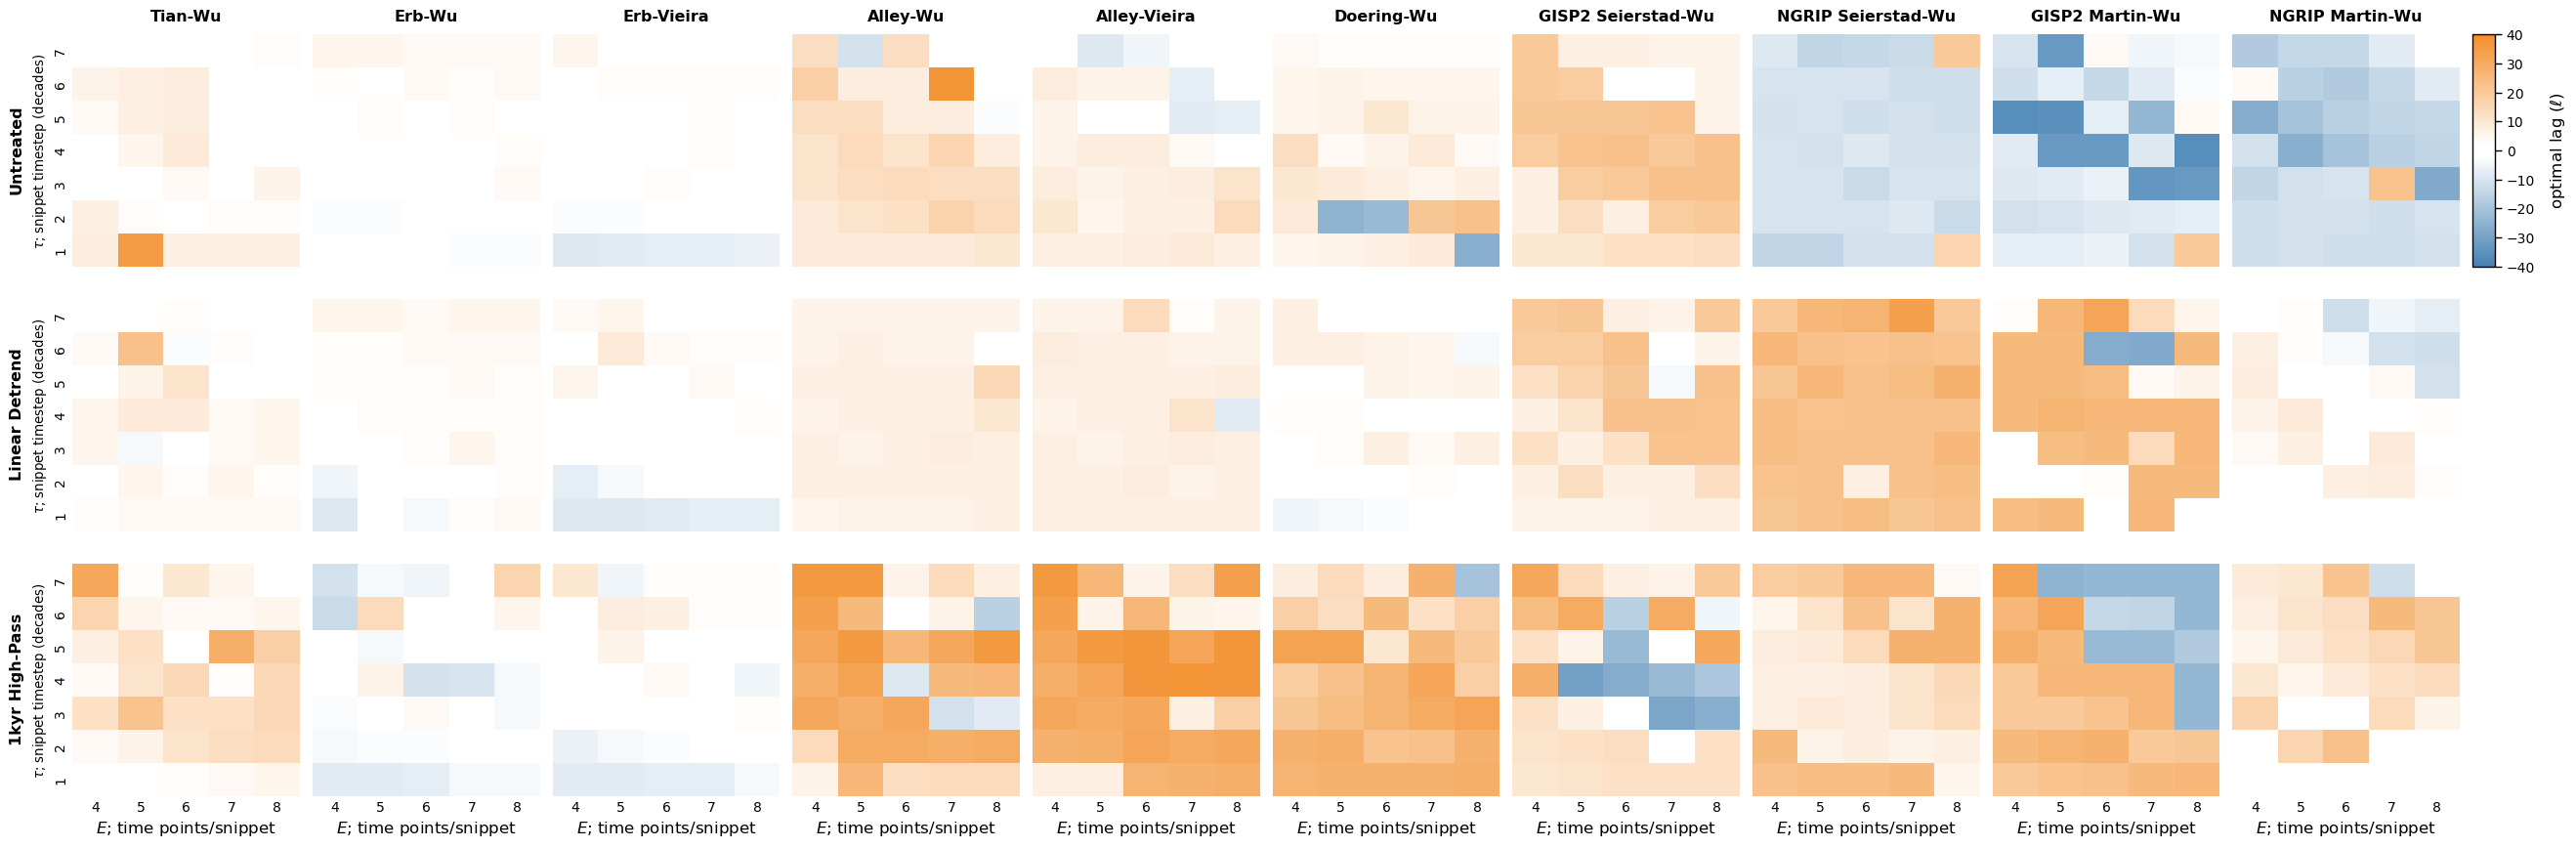

In [6]:
class MultiBreakNorm(mcolors.Normalize):
    def __init__(self, vmin, breaks, vmax, positions=None, clip=False):
        super().__init__(vmin=vmin, vmax=vmax, clip=clip)
        self.breaks = np.asarray(breaks, dtype=float)
        self.positions = ((self.breaks - vmin) / (vmax - vmin)
                          if positions is None else np.asarray(positions, dtype=float))

    def __call__(self, value, clip=None):
        x = np.r_[self.vmin, self.breaks, self.vmax]
        y = np.r_[0.0, self.positions, 1.0]
        return np.ma.masked_array(np.interp(value, x, y))


lag_norm = MultiBreakNorm(vmin=-40, breaks=[-2, 0, 2], vmax=40)
lag_palette = mcolors.LinearSegmentedColormap.from_list(
    "purple_teal_white_orange",
    [(0.00, "steelblue"), (lag_norm.positions[0], "white"),
     (lag_norm.positions[1], "white"), (lag_norm.positions[2], "white"),
     (1.00, "#f28e2b")],
)
lag_grid = make_results_grid(
    "lag", r"optimal lag ($\ell$)", "FigS7_grid_3xn_fullspread__lag",
    palette=lag_palette, show_half_moons=False, norm=lag_norm, vlims=(-40, 40),
    lag_filter=None,
)


### Interpretation

Dyads built on non-δ¹⁸O air-temperature reconstructions (ERB22, and the Döring22
GISP2 series) tend to pick lags close to zero, while δ¹⁸O-based series (ALLEY00,
Seierstad14 GISP2/NGRIP) favor positive lags of roughly 100–200 years (10–20
decadal steps). That fits with δ¹⁸O integrating slower, indirect processes, such as
ocean circulation, sea-ice extent, and moisture source, on top of the direct
air-temperature response. CCM identifies directional predictability, not a physical
response time, so don't read this lag as a literal delay between solar forcing and
its climate response.


### Data requirement

This notebook depends only on `hol_temp_tsi_ccm/mixed/tmp/final_result_grid.parquet`.
Its object grid is rebuilt in memory from the selected `object_grid_precomputed`
rows; no dyad-level outputs are opened.
